# 00 从零理解 LangGraph：用“流程图”把多步骤流程写清楚

## 本章学什么

- **State（状态）**：一张共享的“单子”（一个字典）
- **Node（节点）**：一个步骤（一个 Python 函数）
- **Edge（边）**：步骤之间怎么走（下一步去哪）
- **Graph（图）**：把节点和边装配成一张可执行的流程图

## 解决什么问题

当你的流程从“1 个函数”变成“多步骤 + 分支”，代码很容易变成一坨 if/else/while。LangGraph 让你把流程**显式写成图**：清晰、可观察、可扩展。

## 学完能做什么

- 你能写出一个最小 LangGraph：`START -> ... -> END`
- 你能看懂并解释：每一步 state（字典）是怎么变化的
- 你能写出一个最小分支：根据 state 选择下一步走哪个节点


## 目录

- 一、从一个简单问题开始
- 二、LangGraph 是什么（一句话 + 类比）
- 三、State 到底是什么？（就是字典）
- 四、Node 和 Edge：把步骤连起来
- 五、Demo 1：最小线性图（可观察 state 变化）
- 六、Demo 2：最小分支图（条件边）
- 七、常见坑
- 八、小结


## 一、从一个简单问题开始

假设你要实现一个“审批流程”（比如请假/退款/报销都行）。最简单时你可以写成一个函数：

- 读输入
- 做判断
- 给结果

但现实里流程会变复杂：

- 先登记（写入系统）
- 再根据条件分流（自动通过 / 人工审核）
- 还可能需要回写原因、记录日志

当步骤一多，你会希望它像“**流程图**”一样清晰。LangGraph 就是让你把流程显式写成图。


## 二、LangGraph 是什么？

一句话：**LangGraph 是一个让你用「流程图」的方式组织多步骤流程的工具。**

> **类比：工厂流水线**
>
>- **工位**（Node）= 每个工位做一件事（登记/审核/通知）
>- **传送带**（Edge）= 连接工位，决定下一站去哪
>- **工单**（State）= 产品在流水线上移动时携带的“信息表”（共享字典）
>- **布局图**（Graph）= 把工位和传送带装配成一张图

你只要记住：

> **State 是数据，Node 是步骤，Edge 是连接，Graph 是整体流程图。**


## 三、State 到底是什么？

在本教程里，你可以先把 State 当成：**一个字典**。

我们用 `TypedDict` 把这张“审批单”写得更清楚。比如我们记录：

- `employee`：谁提交
- `days`：请几天
- `reason`：理由
- `status`：当前状态
- `steps`：流程经过了哪些步骤（用于观察）

**关键规则：**节点函数不需要返回整个 state，只需要返回它想修改的那几项（增量 update）。LangGraph 会把 update 合并回 state。


In [1]:
from __future__ import annotations

from typing import TypedDict


class ApprovalState(TypedDict, total=False):
    employee: str
    days: int
    reason: str
    status: str
    steps: list[str]

## 四、Node 和 Edge：把步骤连起来

- **Node（节点）**：就是一个普通 Python 函数，输入 state，返回 update（字典）。
- **Edge（边）**：告诉 LangGraph “这个节点做完后下一步去哪”。

最简单的流程是一条直线：

```text
START -> A -> B -> END
```

接下来我们用两个 Demo 来让你“看见” state 的变化。


## 五、Demo 1：最小线性图（先跑通一条直线）

我们做一个两步线性流程：

```text
START -> submit -> archive -> END
```

- `submit`：把状态改成「已提交」
- `archive`：把状态改成「已归档」

重点观察：

- 你传入的 `init_state` 是什么字典？
- 每个节点返回的 update 是什么字典？
- 合并后的 state（values）如何一步步变化？


In [2]:
from langgraph.graph import END, START, StateGraph


def submit(state: ApprovalState) -> ApprovalState:
    steps = (state.get("steps") or []) + ["submit"]
    return {"status": "已提交", "steps": steps}


def archive(state: ApprovalState) -> ApprovalState:
    steps = (state.get("steps") or []) + ["archive"]
    return {"status": "已归档", "steps": steps}


builder = StateGraph(ApprovalState)
builder.add_node("submit", submit)
builder.add_node("archive", archive)

builder.add_edge(START, "submit")
builder.add_edge("submit", "archive")
builder.add_edge("archive", END)

graph_linear = builder.compile()

print(graph_linear.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	submit(submit)
	archive(archive)
	__end__([<p>__end__</p>]):::last
	__start__ --> submit;
	submit --> archive;
	archive --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### （可选）把线性图画成 PNG

如果你在 Jupyter 里更喜欢“看图”而不是读 Mermaid 文本，可以运行下一格把图渲染成图片。

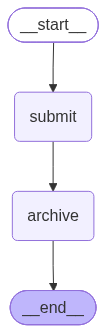

In [3]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod


display(
    Image(
        graph_linear.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [4]:
init_state: ApprovalState = {
    "employee": "小明",
    "days": 2,
    "reason": "感冒",
    "status": "新建",
    "steps": [],
}

print("=== init_state ===")
print(init_state)
print()

print("=== updates（每个节点返回的增量 update）===")
for chunk in graph_linear.stream(init_state, stream_mode="updates"):
    print(chunk)
print()

print("=== values（合并后的 state 快照）===")
for i, snapshot in enumerate(graph_linear.stream(init_state, stream_mode="values")):
    print(f"-- step {i} --")
    print(snapshot)
    print()

=== init_state ===
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '新建', 'steps': []}

=== updates（每个节点返回的增量 update）===
{'submit': {'status': '已提交', 'steps': ['submit']}}
{'archive': {'status': '已归档', 'steps': ['submit', 'archive']}}

=== values（合并后的 state 快照）===
-- step 0 --
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '新建', 'steps': []}

-- step 1 --
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '已提交', 'steps': ['submit']}

-- step 2 --
{'employee': '小明', 'days': 2, 'reason': '感冒', 'status': '已归档', 'steps': ['submit', 'archive']}



### 关键观察（你应该看到什么）

- `updates` 会显示：每个节点各自返回了哪些字段（增量字典）
- `values` 会显示：这些增量如何被合并回 state，所以你会看到 `status` 和 `steps` 一步步变化

到这里，你已经掌握了最小闭环：

- **你提供 init_state（字典）**
- **节点返回 update（字典）**
- **LangGraph 合并 update，沿着边执行下一步**


## 六、Demo 2：最小分支图（条件边）

线性图解决了“多步骤”，但现实流程往往还需要“分支”。

我们做一个最小审批分流：

```text
START -> submit -> (按 days 分流) -> auto_approve / manager_review -> END
```

规则：

- `days <= 1`：自动通过
- `days > 1`：走人工审核

重点观察：同一张图，给不同 init_state，会走不同的边。


In [5]:
from typing import Literal


def auto_approve(state: ApprovalState) -> ApprovalState:
    steps = (state.get("steps") or []) + ["auto_approve"]
    return {"status": "已批准", "steps": steps}


def manager_review(state: ApprovalState) -> ApprovalState:
    steps = (state.get("steps") or []) + ["manager_review"]
    # 这里用一个“固定通过”的规则，避免引入额外复杂性
    return {"status": "已批准", "steps": steps}


def route_after_submit(state: ApprovalState) -> Literal["auto_approve", "manager_review"]:
    return "auto_approve" if int(state.get("days", 0)) <= 1 else "manager_review"


b2 = StateGraph(ApprovalState)
b2.add_node("submit", submit)
b2.add_node("auto_approve", auto_approve)
b2.add_node("manager_review", manager_review)

b2.add_edge(START, "submit")
b2.add_conditional_edges(
    "submit",
    route_after_submit,
    path_map={
        "auto_approve": "auto_approve",
        "manager_review": "manager_review",
    },
)

b2.add_edge("auto_approve", END)
b2.add_edge("manager_review", END)

graph_branch = b2.compile()

print(graph_branch.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	submit(submit)
	auto_approve(auto_approve)
	manager_review(manager_review)
	__end__([<p>__end__</p>]):::last
	__start__ --> submit;
	submit -.-> auto_approve;
	submit -.-> manager_review;
	auto_approve --> __end__;
	manager_review --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### （可选）把分支图画成 PNG

和上面一样，如果你想直观看到分支结构（从 `submit` 分流到 `auto_approve/manager_review`），运行下一格即可。

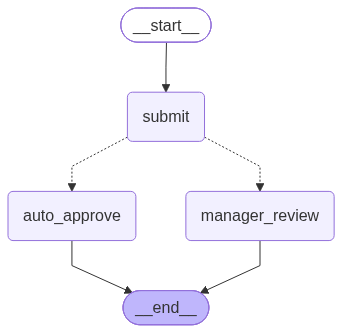

In [6]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod


display(
    Image(
        graph_branch.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [7]:
def run_case(employee: str, days: int, reason: str):
    init: ApprovalState = {
        "employee": employee,
        "days": days,
        "reason": reason,
        "status": "新建",
        "steps": [],
    }

    print("\n=== case ===")
    print("init_state:", init)

    print("--- values（看走了哪条分支）---")
    for i, snapshot in enumerate(graph_branch.stream(init, stream_mode="values")):
        steps = snapshot.get("steps") or []
        print(f"step {i}: status={snapshot.get('status')} steps={steps}")

    out = graph_branch.invoke(init)
    print("--- out ---")
    print(out)


run_case("小明", 1, "感冒")  # days<=1 -> auto_approve
run_case("小红", 3, "回家")  # days>1  -> manager_review


=== case ===
init_state: {'employee': '小明', 'days': 1, 'reason': '感冒', 'status': '新建', 'steps': []}
--- values（看走了哪条分支）---
step 0: status=新建 steps=[]
step 1: status=已提交 steps=['submit']
step 2: status=已批准 steps=['submit', 'auto_approve']
--- out ---
{'employee': '小明', 'days': 1, 'reason': '感冒', 'status': '已批准', 'steps': ['submit', 'auto_approve']}

=== case ===
init_state: {'employee': '小红', 'days': 3, 'reason': '回家', 'status': '新建', 'steps': []}
--- values（看走了哪条分支）---
step 0: status=新建 steps=[]
step 1: status=已提交 steps=['submit']
step 2: status=已批准 steps=['submit', 'manager_review']
--- out ---
{'employee': '小红', 'days': 3, 'reason': '回家', 'status': '已批准', 'steps': ['submit', 'manager_review']}


## 七、常见坑

- **只看最终 out，不看过程**：很难建立直觉。建议先用 `stream(..., stream_mode="values")` 看 state 一步步怎么变。
- **节点里原地修改 state**：例如 `state["steps"].append(...)`。教程阶段尽量用“return 增量 update”的写法（更清晰、更可观察）。
- **条件路由返回值写错**：路由函数返回的值必须能映射到目标节点（要么直接返回节点名，要么配 `path_map`）。


## 八、小结

| 概念 | 一句话解释 | 类比 |
| --- | --- | --- |
| State | 所有节点共享的数据（字典） | 一张审批单 |
| Node | 做一件事的函数，返回增量 update | 流水线工位 |
| Edge | 节点之间的连接，决定下一步去哪 | 传送带 |
| Graph | 把节点和边装配起来的流程图 | 工厂布局图 |
| compile() | 把“草稿图”变成“可执行图” | 把图纸变成流水线 |
| invoke() | 给图一个 init_state，让它跑完并返回最终 state | 把单子送进流水线 |

核心记忆：

> **LangGraph = 用流程图组织多步骤流程；state 是字典；node 返回 update；edge 决定下一步。**
